# Multi-Layer Prognostic Analysis of Pancreatic Adenocarcinoma (TCGA-PAAD)

*Integrating clinical, mutation-burden, copy-number, and hypoxia-signature features to
identify and validate prognostic markers in pancreatic ductal adenocarcinoma, using the
TCGA PanCancer Atlas cohort.*

## Objective

Pancreatic adenocarcinoma (PDAC) remains one of the most lethal solid tumors, and AJCC
stage alone doesn't tell you much about who's actually high risk. This project asks a
simple question: do genomic burden and transcriptomic signature features, layered on
top of routine clinical variables, help identify high-risk patients better than staging
alone? And can that signal be found, and properly validated, using only public data?

The analysis moves through three phases, each one checking the phase before it:

1. **Classical survival analysis**: Kaplan-Meier curves and a multivariate Cox model
2. **ML validation**: a Random Survival Forest benchmarked against Cox using cross-validation
3. **Unsupervised discovery**: clustering that catches and resolves a collinearity
   artifact found in Phase 1

## Data

**Cohort:** TCGA-PAAD, PanCancer Atlas (2018), pulled from cBioPortal. 184 patients
with usable overall survival data. Features include AJCC stage, age, sex, tumor
mutation burden (TMB), fraction of genome altered (FGA), aneuploidy score, three
hypoxia gene-expression signatures (Buffa, Ragnum, Winter), MSIsensor score, and
mutation count.

*Note: this uses TCGA's pre-computed genomic summary scores rather than raw mutation
calls or a full expression matrix. That's a reasonable scope for n=184, not a
shortcut.*


## Setup

In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.inspection import permutation_importance
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
RANDOM_STATE = 42

In [2]:
# ---- Paths: relative to the repo root; run this notebook from there ----
INPUT_CSV = 'data/paad_tcga_pan_can_atlas_2018_clinical_data.tsv'
FIG_DIR = 'figures'
DATA_DIR = 'results'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

## Phase 0: Load and Clean Data

In [3]:
df = pd.read_csv(INPUT_CSV, sep='\t')
df['OS_MONTHS'] = df['Overall Survival (Months)']
df['OS_EVENT'] = df['Overall Survival Status'].str.startswith('1').astype(int)
df = df[df['OS_MONTHS'].notna() & (df['OS_MONTHS'] >= 0)].copy()

def stage_group(s):
    if pd.isna(s):
        return np.nan
    s = str(s)
    if 'IV' in s or 'III' in s:
        return 'III/IV'
    if 'II' in s:
        return 'II'
    if 'I' in s:
        return 'I'
    return np.nan

def stage_num(s):
    return {'I': 1, 'II': 2, 'III/IV': 3}.get(s, np.nan)

df['StageGroup'] = df['Neoplasm Disease Stage American Joint Committee on Cancer Code'].apply(stage_group)
df['StageNum'] = df['StageGroup'].apply(stage_num)
df['SexNum'] = (df['Sex'] == 'Male').astype(int)

# Log-transform right-skewed mutation-burden features (a hypermutated/MSI-high outlier
# is ~250x the cohort median and will distort both linear coefficients and clustering
# distances if left untransformed) -- standard practice for TMB/mutation-count data.
df['log_TMB'] = np.log1p(df['TMB (nonsynonymous)'])
df['log_MutCount'] = np.log1p(df['Mutation Count'])
df['log_MSIsensor'] = np.log1p(df['MSIsensor Score'].clip(lower=0))

def tertile_bin(series, labels=('Low', 'Mid', 'High')):
    return pd.qcut(series, 3, labels=labels, duplicates='drop')

df['TMB_tertile'] = tertile_bin(df['TMB (nonsynonymous)'])
df['FGA_tertile'] = tertile_bin(df['Fraction Genome Altered'])
df['Hypoxia_tertile'] = tertile_bin(df['Buffa Hypoxia Score'])

print(f"N patients with usable survival data: {len(df)}")
print(f"Events (deaths): {df['OS_EVENT'].sum()}")

N patients with usable survival data: 184
Events (deaths): 99


## Phase 1: Classical Survival Analysis

Here I fit Kaplan-Meier curves for AJCC stage, TMB tertiles, FGA tertiles, and hypoxia
score tertiles, then a multivariate Cox proportional hazards model to see which of
these hold up once adjusted for the others.


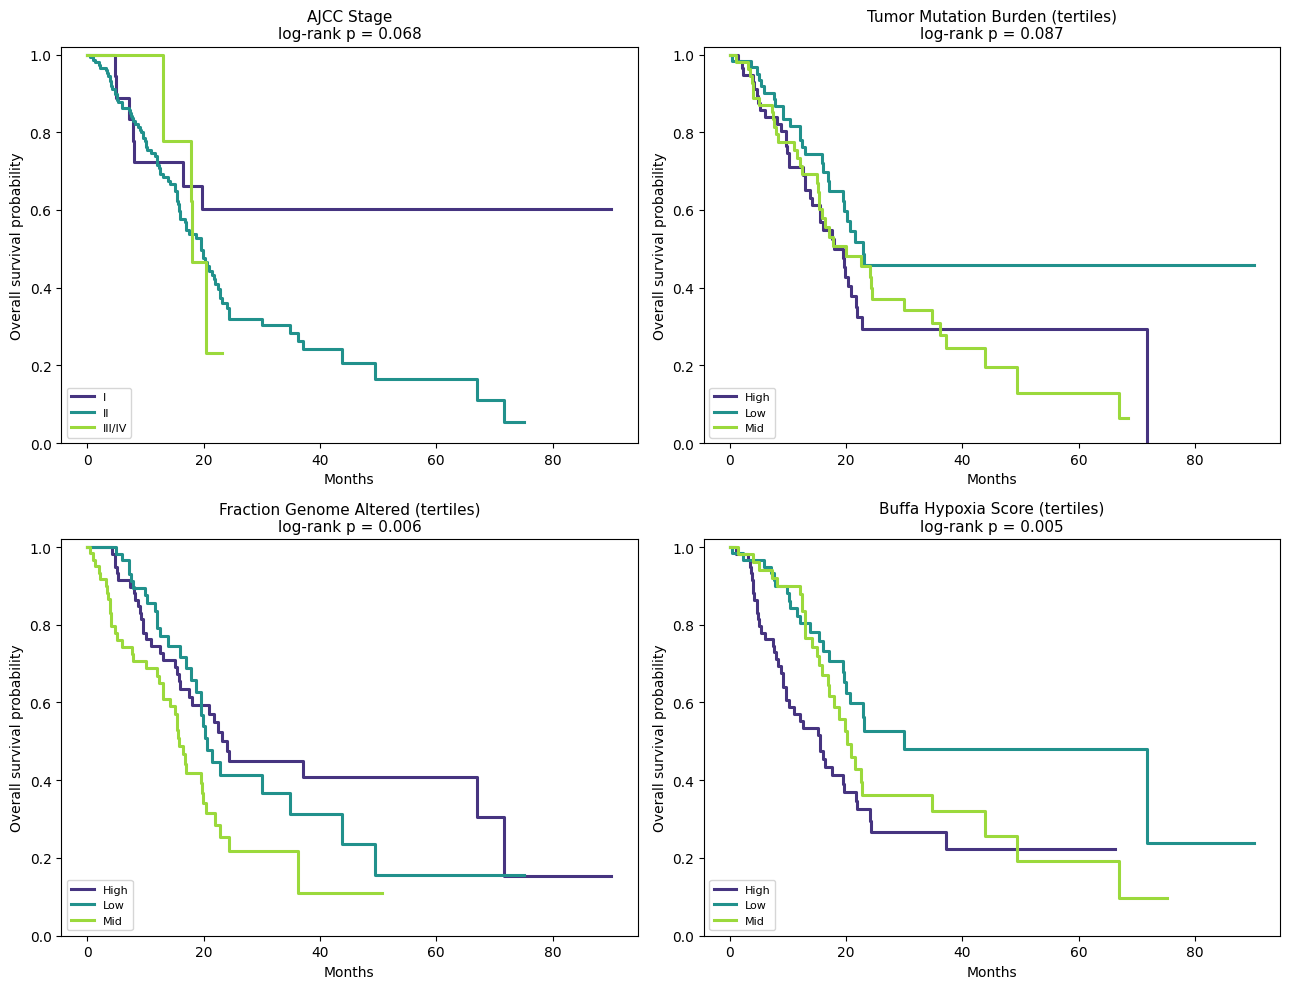

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

def km_panel(ax, group_col, title):
    kmf = KaplanMeierFitter()
    sub = df[df[group_col].notna()]
    groups = sorted(sub[group_col].unique(), key=str)
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(groups)))
    for g, c in zip(groups, colors):
        mask = sub[group_col] == g
        kmf.fit(sub.loc[mask, 'OS_MONTHS'], sub.loc[mask, 'OS_EVENT'], label=str(g))
        kmf.plot_survival_function(ax=ax, ci_show=False, color=c, linewidth=2.2)
    result = multivariate_logrank_test(sub['OS_MONTHS'], sub[group_col], sub['OS_EVENT'])
    ax.set_title(f"{title}\nlog-rank p = {result.p_value:.3f}", fontsize=11)
    ax.set_xlabel('Months'); ax.set_ylabel('Overall survival probability')
    ax.legend(fontsize=8, loc='lower left'); ax.set_ylim(0, 1.02)

km_panel(axes[0, 0], 'StageGroup', 'AJCC Stage')
km_panel(axes[0, 1], 'TMB_tertile', 'Tumor Mutation Burden (tertiles)')
km_panel(axes[1, 0], 'FGA_tertile', 'Fraction Genome Altered (tertiles)')
km_panel(axes[1, 1], 'Hypoxia_tertile', 'Buffa Hypoxia Score (tertiles)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_km_curves.png', dpi=160, bbox_inches='tight')
plt.show()

In [5]:
cox_df = df[['OS_MONTHS', 'OS_EVENT', 'Diagnosis Age', 'StageGroup',
             'TMB (nonsynonymous)', 'Fraction Genome Altered', 'Buffa Hypoxia Score', 'Sex']].dropna().copy()
cox_df = pd.get_dummies(cox_df, columns=['StageGroup', 'Sex'], drop_first=True)
bool_cols = cox_df.select_dtypes(include='bool').columns
cox_df[bool_cols] = cox_df[bool_cols].astype(int)

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='OS_MONTHS', event_col='OS_EVENT')
summary = cph.summary[['coef', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].round(4)
summary.to_csv(f'{DATA_DIR}/01_cox_model_summary.csv')

print(f"Multivariate Cox model (n={len(cox_df)}), concordance = {cph.concordance_index_:.3f}\n")
summary

Multivariate Cox model (n=169), concordance = 0.657



,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,
Diagnosis Age,0.0156,1.0157,0.9955,1.0363,0.1285
TMB (nonsynonymous),0.0002,1.0002,0.9961,1.0044,0.9138
Fraction Genome Altered,-2.2410,0.1064,0.0240,0.4704,0.0031
Buffa Hypoxia Score,0.0245,1.0249,1.0126,1.0372,0.0001
StageGroup_II,0.5880,1.8004,0.8266,3.9213,0.1387
StageGroup_III/IV,0.0091,1.0091,0.2585,3.9398,0.9895
Sex_Male,-0.1237,0.8836,0.5800,1.3462,0.5646


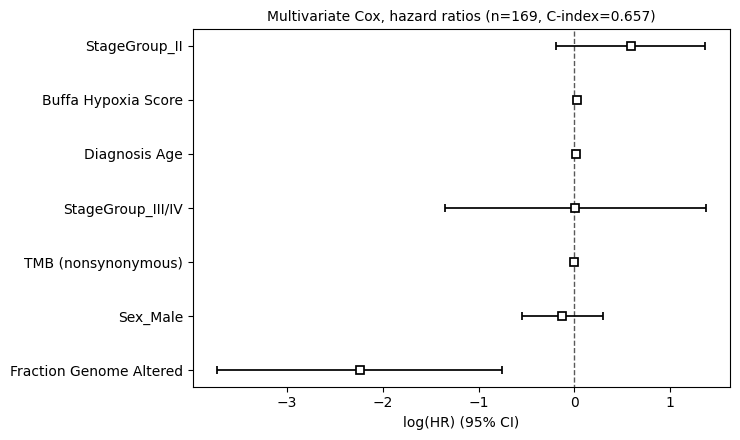

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
cph.plot(ax=ax)
ax.set_title(f'Multivariate Cox, hazard ratios (n={len(cox_df)}, C-index={cph.concordance_index_:.3f})', fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_cox_forest_plot.png', dpi=160, bbox_inches='tight')
plt.show()

> **Flag:** Fraction Genome Altered comes out with HR < 1 here, meaning it looks
> protective. That runs against what we'd expect from genomic instability biology, so
> I'm not taking it at face value. It gets checked again in Phase 3 against a method
> that doesn't assume any of this structure.


## Phase 2: ML Validation, Cox vs. Random Survival Forest

Here I benchmark the linear Cox model against a Random Survival Forest using 5-fold
cross-validation, to check whether nonlinear or interaction effects are being missed,
and to rank features by permutation importance.


In [7]:
FEATURES = ['Diagnosis Age', 'SexNum', 'StageNum', 'log_TMB', 'Fraction Genome Altered',
            'Aneuploidy Score', 'Buffa Hypoxia Score', 'Ragnum Hypoxia Score',
            'Winter Hypoxia Score', 'log_MSIsensor', 'log_MutCount']

model_df = df[FEATURES + ['OS_MONTHS', 'OS_EVENT']].copy()
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(model_df[FEATURES]), columns=FEATURES, index=model_df.index)
y = Surv.from_dataframe('OS_EVENT', 'OS_MONTHS', model_df)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cox_scores, rsf_scores = [], []
X_arr = X.values
for train_idx, test_idx in kf.split(X_arr):
    X_train, X_test = X_arr[train_idx], X_arr[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    cox = CoxPHSurvivalAnalysis(alpha=0.1)
    cox.fit(X_train_s, y_train)
    cox_scores.append(concordance_index_censored(y_test['OS_EVENT'], y_test['OS_MONTHS'], cox.predict(X_test_s))[0])

    rsf = RandomSurvivalForest(n_estimators=300, min_samples_split=10, min_samples_leaf=8,
                                max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE)
    rsf.fit(X_train, y_train)
    rsf_scores.append(concordance_index_censored(y_test['OS_EVENT'], y_test['OS_MONTHS'], rsf.predict(X_test))[0])

print(f"Cox PH (regularized):    {np.mean(cox_scores):.3f} +/- {np.std(cox_scores):.3f}")
print(f"Random Survival Forest:  {np.mean(rsf_scores):.3f} +/- {np.std(rsf_scores):.3f}")
print("--> Statistically indistinguishable: added nonlinearity doesn't buy predictive")
print("    power here. Reported honestly rather than overstating an 'ML win'.")

Cox PH (regularized):    0.598 +/- 0.084
Random Survival Forest:  0.606 +/- 0.103
--> Statistically indistinguishable: added nonlinearity doesn't buy predictive
    power here. Reported honestly rather than overstating an 'ML win'.


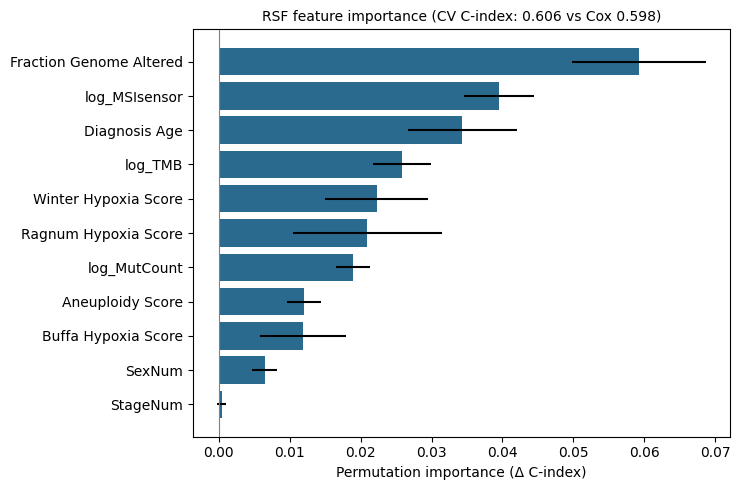

,feature,importance_mean,importance_std
4,Fraction Genome Altered,0.059221,0.009449
9,log_MSIsensor,0.039535,0.004900
0,Diagnosis Age,0.034326,0.007685
3,log_TMB,0.025870,0.004061
8,Winter Hypoxia Score,0.022278,0.007247
7,Ragnum Hypoxia Score,0.020931,0.010492
10,log_MutCount,0.018981,0.002404
5,Aneuploidy Score,0.012038,0.002370
6,Buffa Hypoxia Score,0.011852,0.006092
1,SexNum,0.006433,0.001701


In [8]:
rsf_full = RandomSurvivalForest(n_estimators=500, min_samples_split=10, min_samples_leaf=8,
                                 max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE)
rsf_full.fit(X.values, y)
perm = permutation_importance(rsf_full, X.values, y, n_repeats=20, random_state=RANDOM_STATE)
imp_df = pd.DataFrame({'feature': FEATURES, 'importance_mean': perm.importances_mean,
                        'importance_std': perm.importances_std}).sort_values('importance_mean', ascending=False)
imp_df.to_csv(f'{DATA_DIR}/02_rsf_feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(7.5, 5))
order = imp_df.sort_values('importance_mean')
ax.barh(order['feature'], order['importance_mean'], xerr=order['importance_std'], color='#2b6a8f')
ax.set_xlabel("Permutation importance (Δ C-index)")
ax.set_title(f"RSF feature importance (CV C-index: {np.mean(rsf_scores):.3f} vs Cox {np.mean(cox_scores):.3f})", fontsize=10)
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_rsf_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

imp_df

## Phase 3: Unsupervised Clustering, Resolving the Phase 1 Puzzle

Here I cluster patients on genomic burden and hypoxia features alone, without giving
the algorithm any survival information, to see whether natural molecular subgroups
exist and whether they relate to outcome at all.


In [9]:
cluster_features = ['log_TMB', 'Fraction Genome Altered', 'Aneuploidy Score',
                     'Buffa Hypoxia Score', 'Ragnum Hypoxia Score', 'Winter Hypoxia Score', 'log_MutCount']
X_clust_scaled = StandardScaler().fit_transform(X[cluster_features])

sil_scores = {k: silhouette_score(X_clust_scaled, KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_clust_scaled))
              for k in [2, 3, 4]}
best_k = max(sil_scores, key=sil_scores.get)
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
model_df['Cluster'] = km.fit_predict(X_clust_scaled)

cluster_profile = model_df.groupby('Cluster')[cluster_features].mean().round(2)
cluster_profile.to_csv(f'{DATA_DIR}/03_cluster_profiles.csv')
print(f"Chosen k={best_k} (silhouette scores: {sil_scores})\n")
cluster_profile

Chosen k=2 (silhouette scores: {2: 0.3446716315509404, 3: 0.32804346575726007, 4: 0.3223731253762726})



,log_TMB,Fraction Genome Altered,Aneuploidy Score,Buffa Hypoxia Score,Ragnum Hypoxia Score,Winter Hypoxia Score,log_MutCount
Cluster,,,,,,,
0,0.99,0.23,13.96,8.41,0.64,17.26,3.84
1,0.58,0.07,4.65,-24.19,-13.23,-21.02,2.91


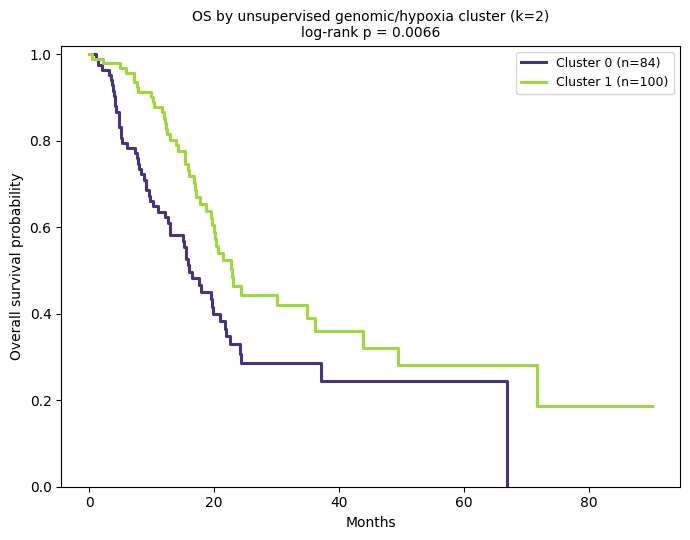

log-rank p = 0.0066



,n,deaths,median_OS_months
Cluster,,,
0,84,54,14.761482
1,100,45,15.862840


In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
kmf = KaplanMeierFitter()
colors = plt.cm.viridis(np.linspace(0.15, 0.85, best_k))
for c, color in zip(sorted(model_df['Cluster'].unique()), colors):
    mask = model_df['Cluster'] == c
    kmf.fit(model_df.loc[mask, 'OS_MONTHS'], model_df.loc[mask, 'OS_EVENT'], label=f'Cluster {c} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, ci_show=False, color=color, linewidth=2.2)
result = multivariate_logrank_test(model_df['OS_MONTHS'], model_df['Cluster'], model_df['OS_EVENT'])
ax.set_title(f"OS by unsupervised genomic/hypoxia cluster (k={best_k})\nlog-rank p = {result.p_value:.4f}", fontsize=10)
ax.set_xlabel('Months'); ax.set_ylabel('Overall survival probability')
ax.legend(fontsize=9); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_cluster_survival.png', dpi=160, bbox_inches='tight')
plt.show()

surv_by_cluster = model_df.groupby('Cluster').agg(n=('OS_EVENT', 'size'), deaths=('OS_EVENT', 'sum'),
                                                   median_OS_months=('OS_MONTHS', 'median'))
print(f"log-rank p = {result.p_value:.4f}\n")
surv_by_cluster

> **Resolution:** the cluster with higher FGA, aneuploidy, and hypoxia scores has
> worse survival, which is the direction we'd actually expect biologically. That
> directly contradicts the sign of FGA's coefficient in the Phase 1 Cox model. The
> most likely explanation is that FGA and hypoxia score are correlated enough that the
> linear model's coefficients got distorted by collinearity. Once hypoxia absorbed the
> instability signal, FGA's fitted coefficient flipped to compensate.
>
> So the takeaway is to trust the hypoxia signal, and not report the raw multivariate
> FGA hazard ratio without this caveat.


## Discussion

The headline finding is that a hypoxia gene-expression signature turns out to be a
more robust prognostic marker than AJCC stage in this cohort. That's a real, if
preliminary, case for adding transcriptomic risk stratification alongside routine
staging in PDAC, and it connects to a therapeutic class that's already being trialed
in pancreatic cancer (hypoxia-activated prodrugs like evofosfamide).

Just as important is what happened with the analysis itself. A single multivariate
model produced a misleading coefficient, and the only reason it got caught was that I
deliberately cross-checked it against an independent, non-parametric method. Treating
a counterintuitive result as something to verify, rather than something to report
as-is, is really the methodological core of this project.

## Limitations

- n=184 is modest for machine learning, so these results should be read as
  hypothesis-generating rather than clinically validated.
- There's no external or held-out cohort. Cross-validation protects against
  overfitting to noise within this cohort, but not against cohort-specific biases,
  like the fact that TCGA-PAAD is enriched for resected, treatment-naive tumors.
- The analysis uses genomic summary scores rather than gene-level mutation calls or a
  full expression matrix.

## Future Directions

- Bring in gene-level driver mutation status (KRAS, TP53, SMAD4, CDKN2A) from the raw
  MAF file.
- Add an expression-based immune-infiltration signature score, to test whether
  hypoxia's prognostic effect is actually mediated by an immunosuppressive
  microenvironment.
- Validate the hypoxia-score finding in an independent cohort, such as ICGC-PACA.
